In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers


2026-01-31 19:38:00.117587: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-31 19:38:02.047544: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-31 19:38:09.488979: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
def generate_sine_wave(samples=10000):
    x = np.linspace(0, 100, samples)
    return np.sin(x)

series = generate_sine_wave()


In [3]:
def create_sequences(data, window_size):
    X = []
    y = []
    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])
    return np.array(X), np.array(y)

window_size = 50

X, y = create_sequences(series, window_size)


In [4]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


In [5]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]


In [6]:
model = keras.Sequential([
    layers.Input(shape=(window_size, 1)),
    layers.LSTM(64),
    layers.Dense(1)
])


2026-01-31 19:54:39.589906: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [7]:
model.compile(
    optimizer="adam",
    loss="mse"
)


In [8]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)


Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 39ms/step - loss: 0.0237 - val_loss: 0.0014
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 8.0067e-04 - val_loss: 1.4953e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 2.0479e-05 - val_loss: 3.6962e-06
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step - loss: 2.1449e-06 - val_loss: 1.7611e-06
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - loss: 1.2182e-06 - val_loss: 9.7000e-07
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 8.4720e-07 - val_loss: 8.7899e-07
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 7.5436e-07 - val_loss: 1.1650e-06
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - loss: 7.2195e-07 - val_loss: 7.0458e-07
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 7.4803e-07 - val_loss: 6.4091e-07
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 6.2866e-07 - val_loss: 5.9958e-07


In [9]:
predictions = model.predict(X_test)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step


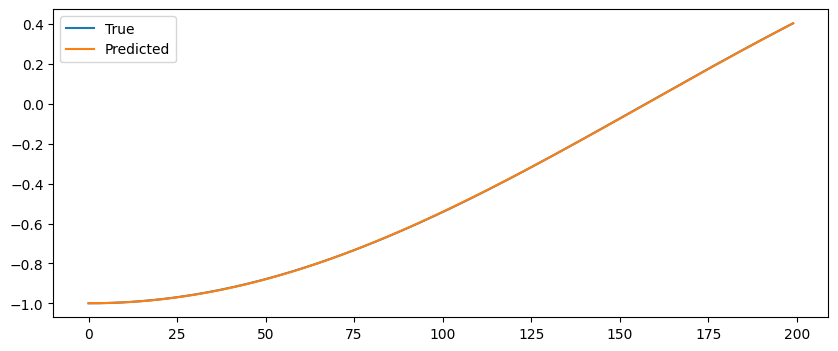

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(y_test[:200], label="True")
plt.plot(predictions[:200], label="Predicted")
plt.legend()
plt.show()
